# **RDF-граф**

# Классификация мошеннических звонков

##Установка библиотеки RDF

In [ ]:
!pip install rdflib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 8.4 MB/s eta 0:00:00


##Загрузка JSON-файла

In [ ]:
from google.colab import files
import json

uploaded = files.upload()

filename = list(uploaded.keys())[0]

with open(filename, "r", encoding="utf-8") as f:
    data = json.load(f)

Saving data.json to data.json


##Создание RDF-графа и namespace

In [ ]:
from rdflib import Graph, Namespace, Literal, RDF
from rdflib.namespace import RDFS, XSD

g = Graph()

EX = Namespace("http://example.org/scam/")
g.bind("ex", EX)

##Онтология (КЛАССЫ И СВОЙСТВА)

In [ ]:
# Classes
g.add((EX.Communication, RDF.type, RDFS.Class))
g.add((EX.Utterance, RDF.type, RDFS.Class))
g.add((EX.Sentence, RDF.type, RDFS.Class))
g.add((EX.Token, RDF.type, RDFS.Class))
g.add((EX.Participant, RDF.type, RDFS.Class))

# Object properties
g.add((EX.hasUtterance, RDF.type, RDF.Property))
g.add((EX.hasSentence, RDF.type, RDF.Property))
g.add((EX.hasParticipant, RDF.type, RDF.Property))

# Data properties (мультимодальность)
g.add((EX.text, RDF.type, RDF.Property))
g.add((EX.intent, RDF.type, RDF.Property))
g.add((EX.emotion, RDF.type, RDF.Property))
g.add((EX.discourseAct, RDF.type, RDF.Property))

g.add((EX.energy, RDF.type, RDF.Property))
g.add((EX.pitch, RDF.type, RDF.Property))
g.add((EX.tempo, RDF.type, RDF.Property))

<Graph identifier=N9038711deea141d689b59d51348c5dc2 (<class 'rdflib.graph.Graph'>)>

##Генерация URI

In [ ]:
def C(cid):
    return EX[f"comm_{cid}"]

def U(cid, uid):
    return EX[f"comm_{cid}_utt_{uid}"]

def S(cid, uid, sid):
    return EX[f"comm_{cid}_utt_{uid}_sent_{sid}"]

def T(cid, uid, sid, tid):
    return EX[f"comm_{cid}_utt_{uid}_sent_{sid}_tok_{tid}"]

def P(pid):
    return EX[f"participant_{pid}"]

##Построение графа: Communication уровень

In [ ]:
for comm in data["communications"]:
    c = C(comm["communication_id"])

    g.add((c, RDF.type, EX.Communication))
    g.add((c, EX.classType, Literal(comm["class"])))
    g.add((c, EX.language, Literal(comm["language"])))

##Роли участников

In [ ]:
    for p in comm["participants"]:
        p_uri = P(p["participant_id"])

        g.add((p_uri, RDF.type, EX.Participant))
        g.add((p_uri, EX.role, Literal(p["role"])))

        g.add((c, EX.hasParticipant, p_uri))

##Audio метаданные

In [ ]:
    audio = comm["audio"]

    g.add((c, EX.audioId, Literal(audio["audio_id"])))
    g.add((c, EX.duration, Literal(audio["duration"], datatype=XSD.float)))
    g.add((c, EX.sampleRate, Literal(audio["sample_rate"], datatype=XSD.int)))

<Graph identifier=N9038711deea141d689b59d51348c5dc2 (<class 'rdflib.graph.Graph'>)>

##Utterances

In [ ]:
    for utt in comm["utterances"]:
        u = U(comm["communication_id"], utt["utterance_id"])

        g.add((u, RDF.type, EX.Utterance))
        g.add((c, EX.hasUtterance, u))

        # текст и прагматика
        g.add((u, EX.text, Literal(utt["text"])))
        g.add((u, EX.intent, Literal(utt["intent"])))
        g.add((u, EX.emotion, Literal(utt["emotion"])))
        g.add((u, EX.discourseAct, Literal(utt["discourse_act"])))

        # паралингвистика (важно для мультимодальности)
        par = utt["paralinguistics"]

        g.add((u, EX.energy, Literal(par["energy"], datatype=XSD.float)))
        g.add((u, EX.pitch, Literal(par["pitch"], datatype=XSD.int)))
        g.add((u, EX.tempo, Literal(par["tempo"], datatype=XSD.int)))

##Sentences

In [ ]:
    for sent in comm["sentences"]:
        s = S(comm["communication_id"], sent["utterance_id"], sent["sentence_id"])
        u = U(comm["communication_id"], sent["utterance_id"])

        g.add((s, RDF.type, EX.Sentence))
        g.add((u, EX.hasSentence, s))

        g.add((s, EX.text, Literal(sent["text"])))

##Tokens + Morphology (лингвистический слой)

In [ ]:
    for tok in comm["tokens"]:
        t = T(comm["communication_id"],
              "U1",
              tok["sentence_id"],
              tok["token_id"])

        g.add((t, RDF.type, EX.Token))
        g.add((t, EX.token, Literal(tok["token"])))
        g.add((t, EX.position, Literal(tok["position"], datatype=XSD.int)))

    for morph in comm["morphology"]:
        tok_uri = EX[f"token_{morph['token_id']}"]

        g.add((tok_uri, EX.lemma, Literal(morph["lemma"])))
        g.add((tok_uri, EX.pos, Literal(morph["pos"])))

##Сохранение RDF-графа

In [ ]:
g.serialize("graph.ttl", format="turtle")
print("RDF graph saved as graph.ttl")
print("Triples:", len(g))

RDF graph saved as graph.ttl
Triples: 165


##Текстовая визуализация

In [ ]:
def view(graph, limit=60):
    for i, (s, p, o) in enumerate(graph):
        print(f"{s} -> {p} -> {o}")
        if i > limit:
            break

view(g)

http://example.org/scam/comm_C3_utt_U1_sent_S18_tok_T60 -> http://example.org/scam/position -> 4
http://example.org/scam/comm_C3_utt_U10_sent_S17 -> http://www.w3.org/1999/02/22-rdf-syntax-ns#type -> http://example.org/scam/Sentence
http://example.org/scam/comm_C3 -> http://example.org/scam/hasParticipant -> http://example.org/scam/participant_P5
http://example.org/scam/participant_P5 -> http://example.org/scam/role -> support
http://example.org/scam/comm_C3_utt_U1_sent_S18_tok_T59 -> http://example.org/scam/position -> 3
http://example.org/scam/comm_C3_utt_U1_sent_S17_tok_T50 -> http://example.org/scam/position -> 6
http://example.org/scam/Participant -> http://www.w3.org/1999/02/22-rdf-syntax-ns#type -> http://www.w3.org/2000/01/rdf-schema#Class
http://example.org/scam/comm_C3_utt_U1_sent_S17_tok_T46 -> http://www.w3.org/1999/02/22-rdf-syntax-ns#type -> http://example.org/scam/Token
http://example.org/scam/comm_C2 -> http://www.w3.org/1999/02/22-rdf-syntax-ns#type -> http://example.o

#SPARQL запросы

##Средний уровень энергии

In [ ]:
q2 = """
SELECT (AVG(?energy) AS ?avgEnergy)
WHERE {
  ?u ex:energy ?energy .
}
"""
for r in g.query(q2):
    print(r)

(rdflib.term.Literal('0.01', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#double')),)


##Intent распределение

In [ ]:
q3 = """
SELECT ?intent (COUNT(?u) AS ?count)
WHERE {
  ?u ex:intent ?intent .
}
GROUP BY ?intent
ORDER BY DESC(?count)
"""
for r in g.query(q3):
    print(r)

(rdflib.term.Literal('transaction_verification'), rdflib.term.Literal('1', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.Literal('approval'), rdflib.term.Literal('1', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))


##Роли участников

In [ ]:
q4 = """
SELECT ?role (COUNT(?p) AS ?count)
WHERE {
  ?c ex:hasParticipant ?p .
  ?p ex:role ?role .
}
GROUP BY ?role
"""
for r in g.query(q4):
    print(r)

(rdflib.term.Literal('support'), rdflib.term.Literal('1', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.Literal('client'), rdflib.term.Literal('1', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))


#Визуализация графа

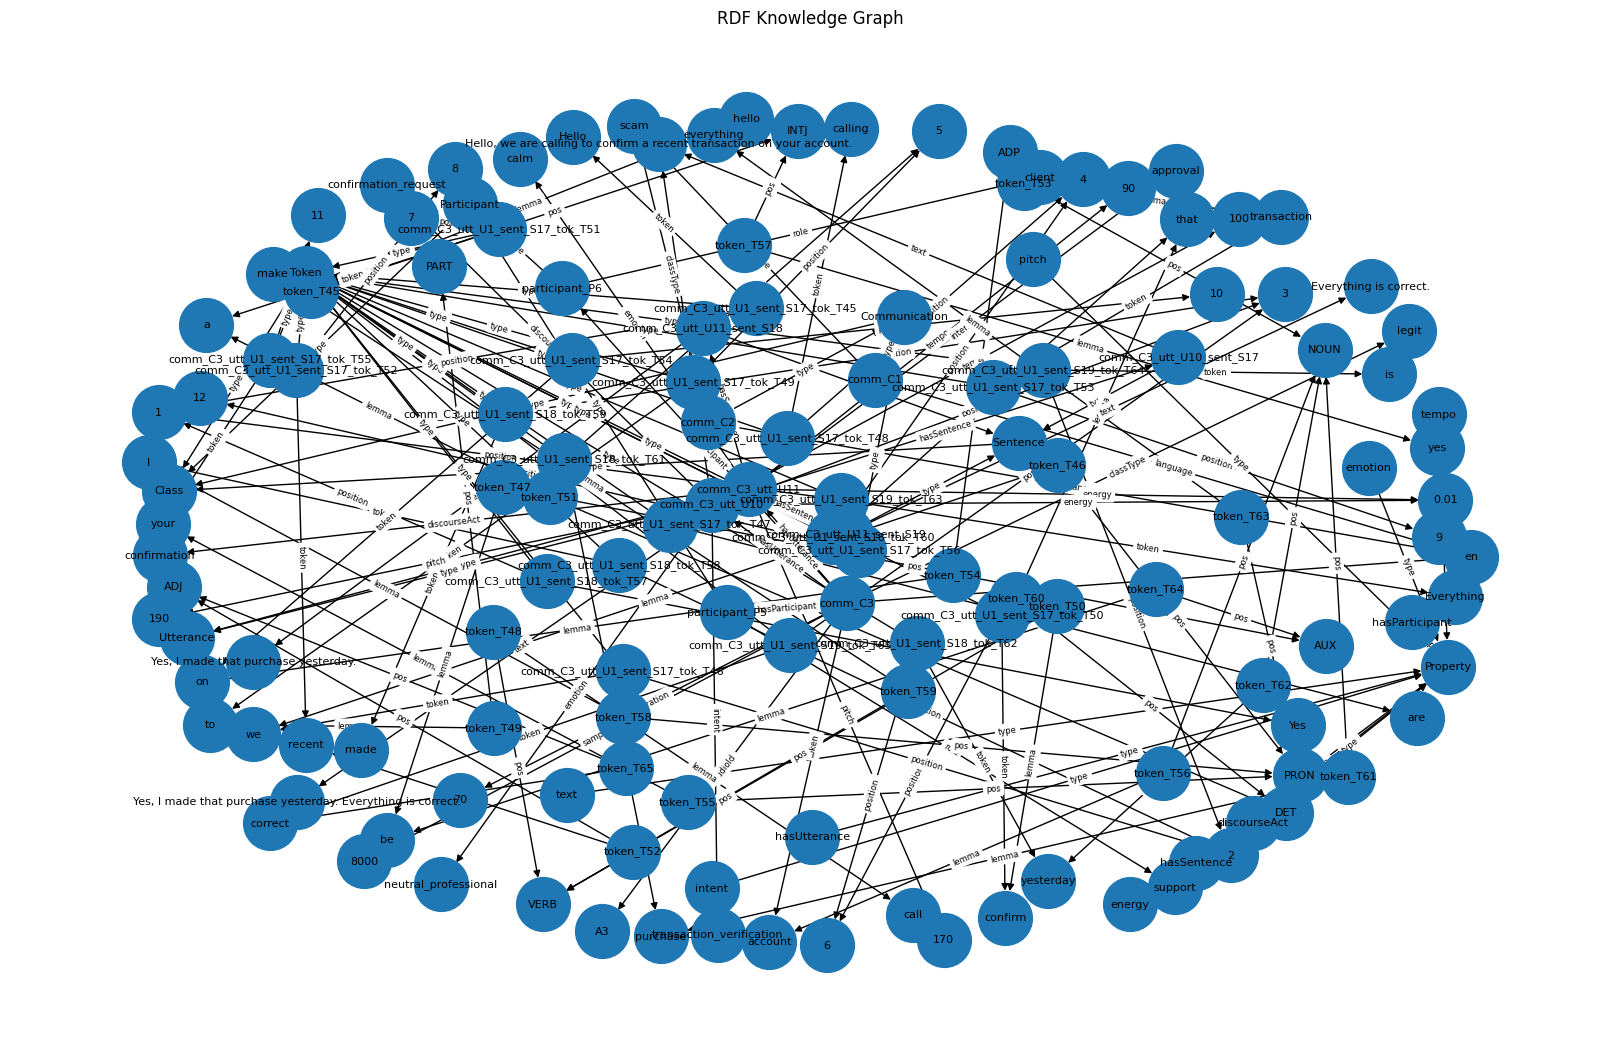

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# создаём более читаемые узлы (обрезаем URI)
def short(x):
    x = str(x)
    if "#" in x:
        return x.split("#")[-1]
    return x.split("/")[-1]

# добавляем ребра + подписи связей
for s, p, o in g:
    s_ = short(s)
    p_ = short(p)
    o_ = short(o)

    G.add_edge(s_, o_, label=p_)

plt.figure(figsize=(16, 10))
pos = nx.spring_layout(G, k=0.7)

# узлы
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1500,
    font_size=8
)

# подписи рёбер
edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=6
)

plt.title("RDF Knowledge Graph")
plt.show()